# Shape Reconstruction Inspection

Load the trained OrganoidVAE and visualise original vs reconstructed meshes.

**Architecture:** DiffusionNet encoder (HKS → global mean pool → μ/log-var) +
AtlasNet-style decoder (Groueix et al. 2018, single-patch):
`conv(sphere_coords) + proj_z(z)` additive injection → BatchNorm1d + ReLU hidden
layers → 3-D output. Random sphere points are used during training; the fixed
icosphere is used at eval time.

Use this notebook to assess whether the network is learning meaningful shape
representations after retraining with the new architecture.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from meshplot import plot

sys.path.insert(0, os.path.join(os.getcwd()))
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', '..'))

from model import OrganoidVAE
from dataset import OrganoidDataset
from train import chamfer_distance, chamfer_procrustes, generate_icosphere

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')


def _to_device(t, device):
    """Move tensor to device; densify sparse tensors for MPS (no sparse backend)."""
    if device.type == 'mps' and t.is_sparse:
        return t.to_dense().to(device)
    return t.to(device)


Device: mps


In [2]:
import json

# --- Configuration: adjust these to match your training run ---
data_path = '../../../Data/small_meshes'
output_dir = 'outputs'

model_path = os.path.join(output_dir, 'model_final.pt')
# model_path = os.path.join(output_dir, 'model_checkpoint.pt') 
sphere_template_path = os.path.join(output_dir, 'sphere_template.pt')

param_path = os.path.join(output_dir, 'config.json')

# Load hyperparameters from config.json

with open(param_path, 'r') as f:
    config = json.load(f)

C_latent = config['C_latent']
C_width = config['C_width']
C_fate = config.get('C_fate', 0)
dec_width = config['dec_width']
dec_layers = config['dec_layers']
k_eig = config['k_eig']
op_cache_dir = config.get('op_cache_dir', '../../op_cache')

print(f'Loaded config: C_latent={C_latent}, C_width={C_width}, dec_width={dec_width}, dec_layers={dec_layers}, k_eig={k_eig}')


Loaded config: C_latent=32, C_width=64, dec_width=128, dec_layers=4, k_eig=128


In [3]:
# Load sphere template
sphere_data = torch.load(sphere_template_path, map_location=device, weights_only=True)
sphere_verts = sphere_data['verts'].to(device)
sphere_faces = sphere_data['faces']
print(f'Sphere template: {sphere_verts.shape[0]} verts, {sphere_faces.shape[0]} faces')

# Load dataset
dataset = OrganoidDataset(
    data_path=data_path,
    k_eig=k_eig,
    op_cache_dir=op_cache_dir,
)

# Load model
n_hks = dataset.n_hks
model = OrganoidVAE(
    C_in=n_hks,
    C_latent=C_latent,
    C_fate=C_fate,
    C_width=C_width,
    dec_width=dec_width,
    dec_layers=dec_layers,
).to(device)


ckpt = torch.load(model_path, map_location=device, weights_only=True)
state_dict = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
model.load_state_dict(state_dict)
model.eval()
print(f'Model loaded from {model_path}')


Sphere template: 2562 verts, 5120 faces
HKS features: 16
OrganoidDataset: 3037 organoids loaded.
Sphere-CD cache: 3038 entries loaded from ../../../Data/small_meshes/sphere_cd_cache.json
BalancedBinSampler: threshold=0.05  spherical=1748  irregular=1289
Model loaded from outputs/model_final.pt


In [4]:

@torch.no_grad()
def reconstruct(model, dataset, idx, sphere_verts, device):
    """Run one sample through the model and return original + reconstructed vertices."""
    sample = dataset[idx]

    hks   = _to_device(sample['hks'],   device)
    verts = _to_device(sample['verts'], device)
    mass  = _to_device(sample['mass'],  device)
    L     = _to_device(sample['L'],     device)
    evals = _to_device(sample['evals'], device)
    evecs = _to_device(sample['evecs'], device)
    gradX = _to_device(sample['gradX'], device)
    gradY = _to_device(sample['gradY'], device)

    p_recon, mu, log_var = model(hks, sphere_verts, mass, L, evals, evecs, gradX, gradY)

    return {
        'verts_orig':  verts.cpu().numpy(),
        'faces_orig':  sample['faces'].numpy(),
        'verts_recon': p_recon.squeeze(0).cpu().numpy(),
        'faces_recon': sphere_faces.cpu().numpy(),
        'z':           mu.squeeze(0).cpu().numpy(),  # posterior mean as embedding
        'id':          sample['meta']['id'],
    }


def plot_mesh_comparison(result):
    """Plot original and reconstructed mesh side by side in separate interactive 3D panels."""
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    def mesh_trace(v, f, name, color, scene):
        return go.Mesh3d(
            x=v[:, 0], y=v[:, 1], z=v[:, 2],
            i=f[:, 0], j=f[:, 1], k=f[:, 2],
            color=color,
            opacity=0.7,
            name=name,
            showscale=False,
            scene=scene,
        )

    v_orig  = result['verts_orig']
    f_orig  = result['faces_orig']
    v_recon = result['verts_recon']
    f_recon = result['faces_recon']

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'mesh3d'}, {'type': 'mesh3d'}]],
        subplot_titles=['Original', 'Reconstructed'],
    )

    fig.add_trace(mesh_trace(v_orig,  f_orig,  'Original',      'steelblue', 'scene1'), row=1, col=1)
    fig.add_trace(mesh_trace(v_recon, f_recon, 'Reconstructed', 'coral',     'scene2'), row=1, col=2)

    scene_kwargs = dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data')
    fig.update_layout(
        title=f'Organoid: {result["id"]}',
        scene=scene_kwargs,
        scene2=scene_kwargs,
        margin=dict(l=0, r=0, t=60, b=0),
        width=650, height=350,
        showlegend=False,
    )
    fig.show()


## Inspect a specific organoid by ID

Change `target_id` below to inspect any organoid.

In [11]:

# Build a mapping from organoid ID to dataset index
id_to_dataset_idx = {dataset.entries[i]['id']: i for i in range(len(dataset))}

# --- Change this to any organoid ID you want to inspect ---
target_id = dataset.entries[5]['id']  # or e.g. 'day4p5_B02_96'

if target_id in id_to_dataset_idx:
    dataset_idx = id_to_dataset_idx[target_id]
    result = reconstruct(model, dataset, dataset_idx, sphere_verts, device)
    plot_mesh_comparison(result)
else:
    print(f'{target_id} not found in dataset. Available IDs:')
    print(list(id_to_dataset_idx.keys())[:10], '...')


In [27]:
sample = dataset[5] 
og_verts = sample['verts']
flipped_verts = og_verts.clone()
flipped_verts[:, 0] *= -1  # Flip Z axis for better alignment

print(chamfer_procrustes(og_verts, flipped_verts))  # Should be small if they are similar
print(chamfer_procrustes(og_verts, og_verts))
from meshplot import plot

plot(og_verts.to('cpu').numpy(), result['faces_orig']) 
plot(flipped_verts.to('cpu').numpy(), result['faces_orig']) 



tensor(0.0840)
tensor(4.6245e-05)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.046749…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0467494…

## Chamfer distance distribution across the dataset

In [6]:
# Compute Chamfer distance for every sample
chamfer_dists = []
recon_ids = []

for idx in range(len(dataset))[::5]:
    result = reconstruct(model, dataset, idx, sphere_verts, device)
    cd = chamfer_procrustes(
        torch.tensor(result['verts_recon']),
        torch.tensor(result['verts_orig'])
    ).item()
    chamfer_dists.append(cd)
    recon_ids.append(result['id'])

chamfer_dists = np.array(chamfer_dists)
print(f'Chamfer distance: mean={chamfer_dists.mean():.6f}, '
      f'median={np.median(chamfer_dists):.6f}, '
      f'max={chamfer_dists.max():.6f}')

Chamfer distance: mean=0.029736, median=0.024880, max=0.109292


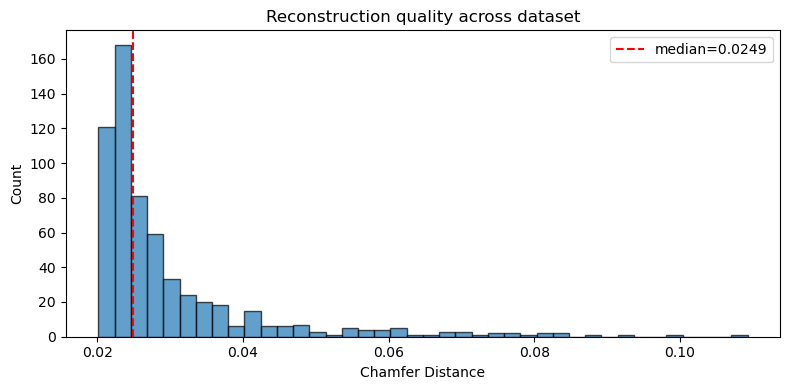


Worst reconstructions:
  day4p5-more_C06_140: CD=0.092847


  day4p5-more_C02_41: CD=0.100116


  day4p5_B06_32: CD=0.109292



Best reconstructions:
  day4_A04_5: CD=0.020135


  day3_A03_37: CD=0.020395


  day4_A02_46: CD=0.020421


In [7]:

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(chamfer_dists, bins=40, edgecolor='k', alpha=0.7)
ax.axvline(np.median(chamfer_dists), color='r', linestyle='--', label=f'median={np.median(chamfer_dists):.4f}')
ax.set_xlabel('Chamfer Distance')
ax.set_ylabel('Count')
ax.set_title('Reconstruction quality across dataset')
ax.legend()
plt.tight_layout()
plt.show()

# Show the worst reconstructions
worst_indices = np.argsort(chamfer_dists)[-3:]
print('\nWorst reconstructions:')
for idx in worst_indices:
    dataset_idx = id_to_dataset_idx.get(recon_ids[idx], idx)
    print(f'  {recon_ids[idx]}: CD={chamfer_dists[idx]:.6f}')
    result = reconstruct(model, dataset, dataset_idx, sphere_verts, device)
    plot_mesh_comparison(result)

# Show the best reconstructions
best_indices = np.argsort(chamfer_dists)[:3]
print('\nBest reconstructions:')
for idx in best_indices:
    dataset_idx = id_to_dataset_idx.get(recon_ids[idx], idx)
    print(f'  {recon_ids[idx]}: CD={chamfer_dists[idx]:.6f}')
    result = reconstruct(model, dataset, dataset_idx, sphere_verts, device)
    plot_mesh_comparison(result)

## Colour tSNE by reconstruction quality

Load latent embeddings (from the clustering notebook) and overlay Chamfer
distance on the tSNE plot.

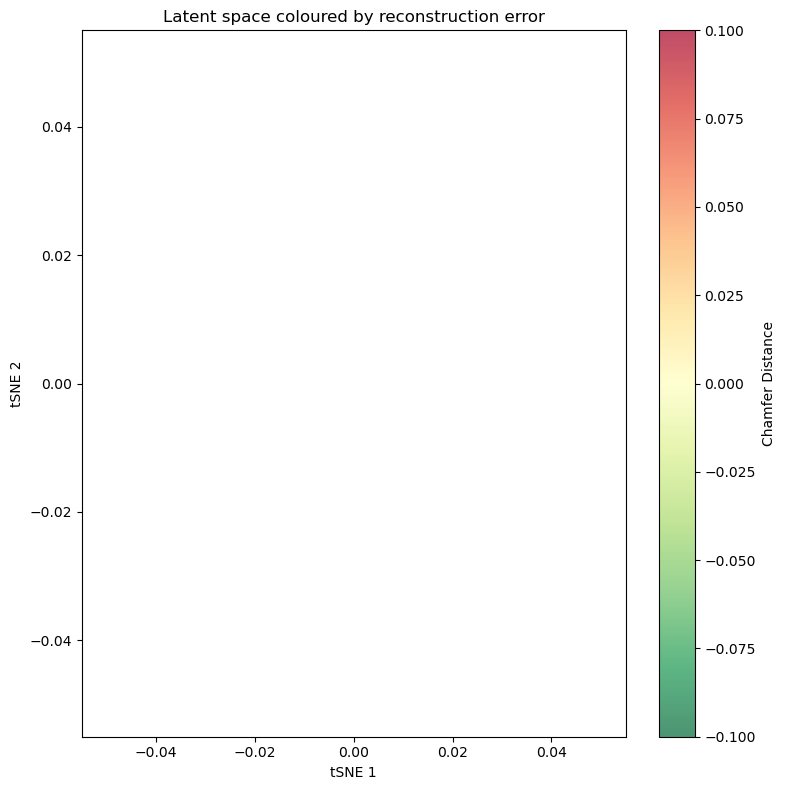

In [49]:
import plotly.graph_objects as go
from sklearn.manifold import TSNE

# Load latent embeddings
res = np.load(os.path.join(output_dir, 'latent_embeddings.npz'), allow_pickle=True)
latents = res['latents'].squeeze()  # shape (N, C_latent)
ids = res['ids']

# Violin plot across all latent dimensions
fig = go.Figure()
for i in range(latents.shape[1]):
    fig.add_trace(go.Violin(
        y=latents[:, i],
        name=f'z{i}',
        box_visible=True,
        meanline_visible=True,
        points='all',
        pointpos=0,
        marker=dict(size=3, opacity=0.4),
    ))
fig.update_layout(
    title='Latent Dimension Distributions',
    xaxis_title='Latent Dimension',
    yaxis_title='Value',
    showlegend=False,
    width=650, height=350,
)
fig.show()

# tSNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_coords = tsne.fit_transform(latents)

# Map Chamfer distances back to the latent embedding ordering
cd_by_id = dict(zip(recon_ids, chamfer_dists))
cd_for_tsne = np.array([cd_by_id.get(oid, np.nan) for oid in ids])

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                c=cd_for_tsne, s=40, alpha=0.7, cmap='RdYlGn_r')
plt.colorbar(sc, label='Chamfer Distance')
ax.set_xlabel('tSNE 1')
ax.set_ylabel('tSNE 2')
ax.set_title('Latent space coloured by reconstruction error')
plt.tight_layout()
plt.show()


## Latent space interpolation

Pick two organoids and interpolate between their latent codes to see how
the decoded shape changes smoothly.

Interpolating between Nday4p5_B02_100 and Nday4p5_B02_115


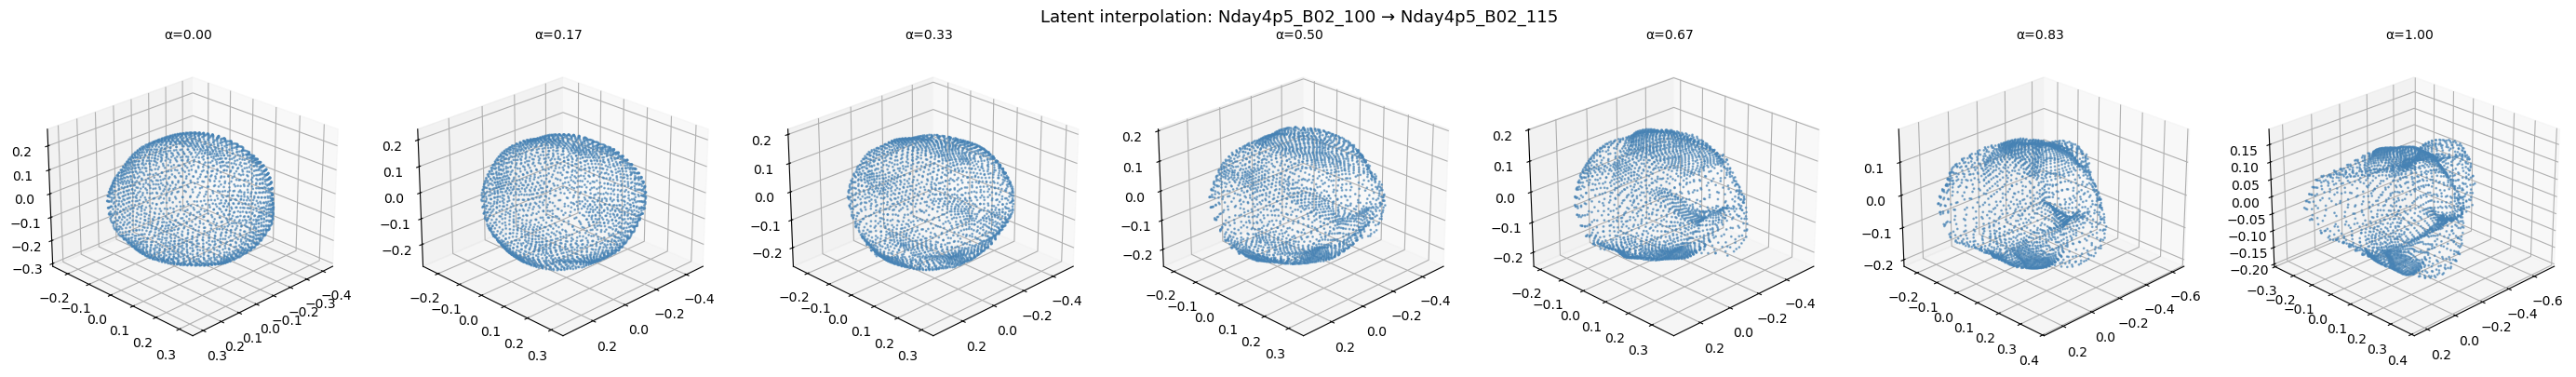

In [50]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Pick two organoid indices ---
idx_a = 0
idx_b = 5



# Encode both
res_a = reconstruct(model, dataset, idx_a, sphere_verts, device)
res_b = reconstruct(model, dataset, idx_b, sphere_verts, device)
z_a = torch.tensor(res_a['z'], device=device).unsqueeze(0)
z_b = torch.tensor(res_b['z'], device=device).unsqueeze(0)

print(f'Interpolating between {res_a["id"]} and {res_b["id"]}')

# Interpolate and decode
n_steps = 7
alphas = np.linspace(0, 1, n_steps)

fig = plt.figure(figsize=(4 * n_steps, 4))
for i, alpha in enumerate(alphas):
    z_interp = (1 - alpha) * z_a + alpha * z_b

    with torch.no_grad():
        p_canonical = model.decoder(z_interp, sphere_verts)
    v = p_canonical.squeeze(0).cpu().numpy()
    f = sphere_faces.cpu().numpy()

    ax = fig.add_subplot(1, n_steps, i + 1, projection='3d')
    ax.scatter(v[:, 0], v[:, 1], v[:, 2], s=1, c='steelblue', alpha=0.6)

    margin = 0.1
    for dim, label in enumerate(['X', 'Y', 'Z']):
        lo, hi = v[:, dim].min(), v[:, dim].max()
        pad = max((hi - lo) * margin, 0.01)
        getattr(ax, f'set_{label.lower()}lim')(lo - pad, hi + pad)

    ax.set_title(f'α={alpha:.2f}', fontsize=10)
    ax.view_init(elev=25, azim=45)

fig.suptitle(f'Latent interpolation: {res_a["id"]} → {res_b["id"]}', fontsize=13)
plt.tight_layout()
plt.show()
